In [1]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inside notebook
%matplotlib inline


In [4]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")


In [5]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
print(fake.shape)
print(true.shape)


(23481, 4)
(21417, 4)


In [8]:
print(fake.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')


In [9]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [10]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [11]:
fake["label"] = 0
true["label"] = 1

In [12]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [13]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [14]:
data = pd.concat([fake, true], ignore_index=True)

In [15]:
data.shape

(44898, 5)

In [16]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [17]:
data = data.dropna()

In [18]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [19]:
print("Before:", data.shape)

data = data.drop_duplicates()

print("After:", data.shape)

Before: (44898, 5)
After: (44689, 5)


In [20]:
data = data.sample(frac=1, random_state=42)

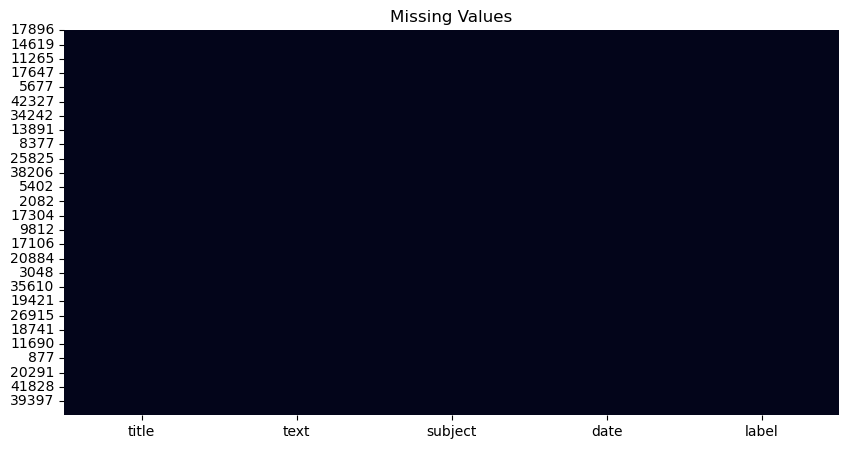

In [21]:
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [22]:
data["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

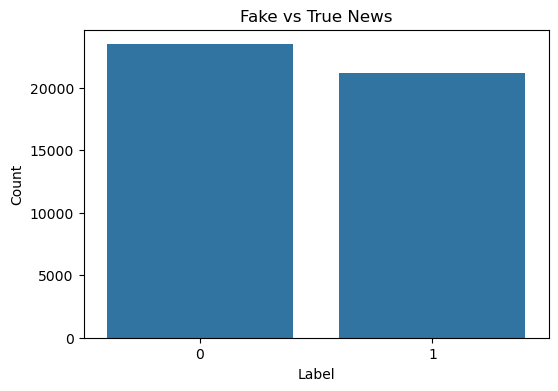

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=data
)

plt.title("Fake vs True News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [24]:
data["text_length"] = data["text"].apply(len)

In [25]:
data[["text_length"]].head()

,text_length
17896,10062
39667,2808
36440,232
21764,610
7557,2658


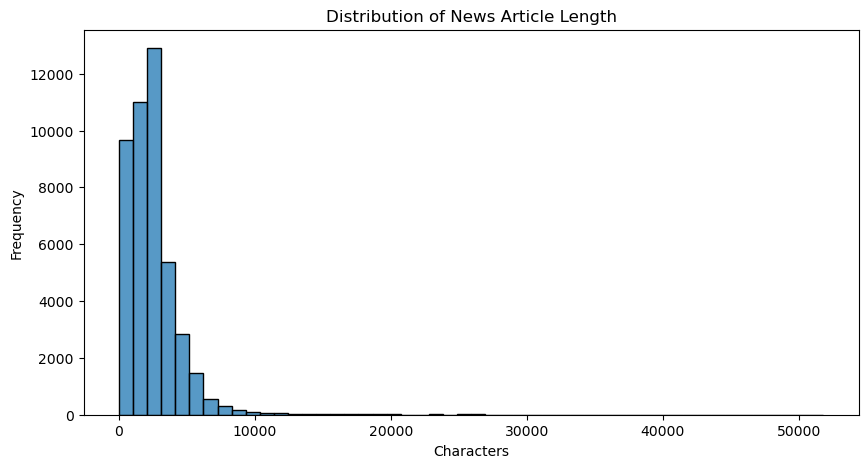

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    data["text_length"],
    bins=50
)

plt.title("Distribution of News Article Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

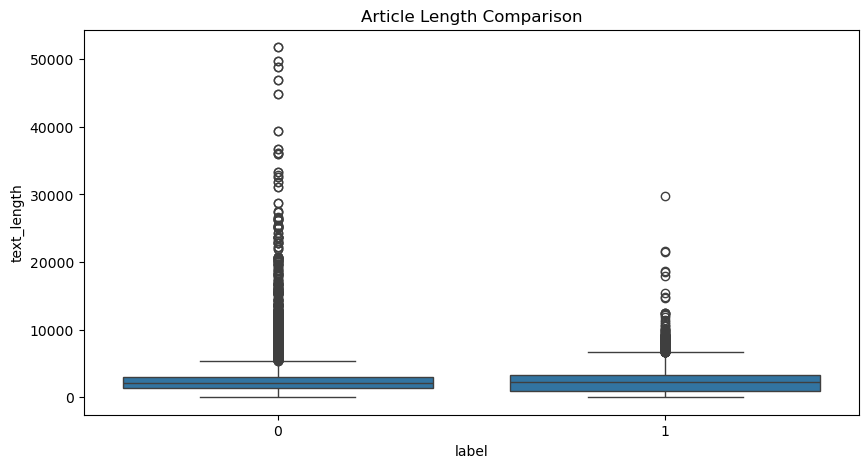

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="label",
    y="text_length",
    data=data
)

plt.title("Article Length Comparison")
plt.show()

In [28]:
data["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

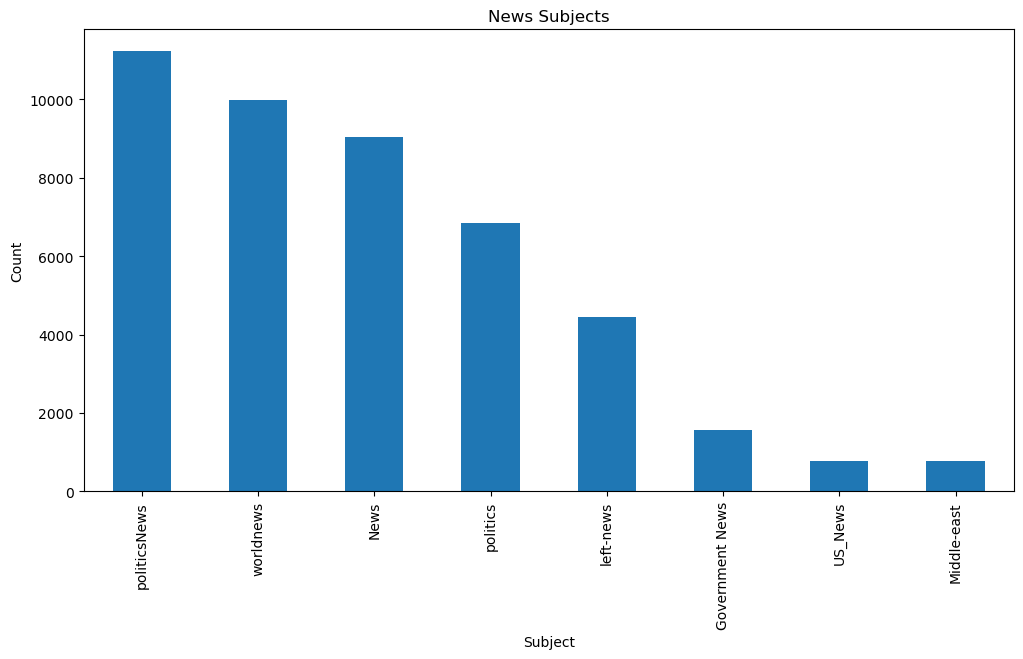

In [29]:
plt.figure(figsize=(12,6))

data["subject"].value_counts().plot(
    kind="bar"
)

plt.title("News Subjects")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

In [30]:
data.to_csv(
    "cleaned_fake_news.csv",
    index=False
)

In [31]:
data.describe()

,label,text_length
count,44689.000000,44689.000000
mean,0.474636,2467.098682
std,0.499362,2173.612347
min,0.000000,1.000000
25%,0.000000,1232.000000
50%,0.000000,2185.000000
75%,1.000000,3101.000000
max,1.000000,51794.000000


In [32]:
data["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

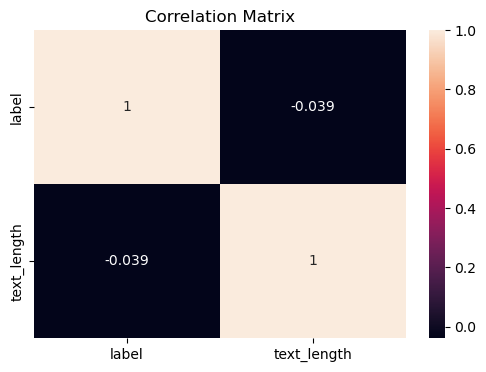

In [33]:
numeric_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_data.corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [1]:
print(X.head())
print(y.head())


NameError: name 'X' is not defined

In [2]:
data.head()

NameError: name 'data' is not defined

In [3]:
import pandas as pd

In [4]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [5]:
fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true], ignore_index=True)

In [6]:
print(data.shape)
data.head()

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [7]:
import joblib

model = joblib.load("fake_news_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [8]:
sample = true.iloc[0]["text"]

pred = model.predict(
    vectorizer.transform([sample])
)

print("Prediction:", pred[0])
print("Expected:", 1)

Prediction: 1
Expected: 1


In [9]:
print("Prediction:", pred[0])
print("Expected:", 1)

Prediction: 1
Expected: 1


In [10]:
import joblib

model = joblib.load("fake_news_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [11]:
import pandas as pd

true = pd.read_csv("True.csv")

In [13]:
sample = true.iloc[0]["text"]

print(sample[:500])

WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they retur


In [14]:
pred = model.predict(
    vectorizer.transform([sample])
)

print(pred[0])

1


In [17]:
print(true.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')


In [18]:
print(true.iloc[0]["title"])

As U.S. budget fight looms, Republicans flip their fiscal script


In [19]:
print(sample)

WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-defense “discretionary” spending on programs that support educati

In [20]:
print(pred[0])

1
